In [ ]:
# Story 16.1 – Mini AI Project

## Sentiment Dashboard using VADER Sentiment Analysis

### Objective

The objective of this project is to analyze customer reviews using the VADER Sentiment Analyzer. 
The project calculates sentiment scores, classifies reviews into Positive, Negative, and Neutral categories, and visualizes the results using charts.

### Tools Used

- Python
- Pandas
- Matplotlib
- NLTK
- VADER Sentiment Analyzer

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [9]:
## Load VADER Sentiment Model


nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Vedika
[nltk_data]     Pingat\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [14]:
# Load Customer Reviews Dataset

import pandas as pd

file_path = r"C:\Users\Vedika Pingat\Intern-Projects\story_13_Text_Data_Basics\data\Women_s_E-Commerce_Clothing_Reviews_1594_1.csv"

df = pd.read_csv(file_path, sep=';')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (23486, 11)


,Unnamed: 0,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
0,1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [15]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               23486 non-null  int64 
 1   Clothing.ID              23486 non-null  int64 
 2   Age                      23486 non-null  int64 
 3   Title                    19676 non-null  object
 4   Review.Text              22641 non-null  object
 5   Rating                   23486 non-null  int64 
 6   Recommended.IND          23486 non-null  int64 
 7   Positive.Feedback.Count  23486 non-null  int64 
 8   Division.Name            23472 non-null  object
 9   Department.Name          23472 non-null  object
 10  Class.Name               23472 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.0+ MB


In [ ]:
## Data Cleaning
#Before performing sentiment analysis, missing review texts must be removed.


In [16]:
df.isnull().sum()

Unnamed: 0                    0
Clothing.ID                   0
Age                           0
Title                      3810
Review.Text                 845
Rating                        0
Recommended.IND               0
Positive.Feedback.Count       0
Division.Name                14
Department.Name              14
Class.Name                   14
dtype: int64

In [17]:
df = df.dropna(subset=['Review.Text'])

In [18]:
print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (22641, 11)


In [ ]:
## Initialize VADER Sentiment Analyzer

#VADER (Valence Aware Dictionary and Sentiment Reasoner) is a rule-based sentiment analysis model.It generates:
- Positive score
- Negative score
- Neutral score
- Compound score
#The compound score is used to determine overall sentiment.

In [19]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

In [20]:
# Test Sentiment Analysis

sample_review = df['Review.Text'].iloc[0]

print(sample_review)
print("\nSentiment Scores:")
print(sia.polarity_scores(sample_review))

Absolutely wonderful - silky and sexy and comfortable

Sentiment Scores:
{'neg': 0.0, 'neu': 0.272, 'pos': 0.728, 'compound': 0.8932}


In [21]:
## Calculate Sentiment Scores for All Reviews
df['Compound_Score'] = df['Review.Text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

df[['Review.Text', 'Compound_Score']].head()

,Review.Text,Compound_Score
0,Absolutely wonderful - silky and sexy and comf...,0.8932
1,Love this dress! it's sooo pretty. i happene...,0.9729
2,I had such high hopes for this dress and reall...,0.9427
3,"I love, love, love this jumpsuit. it's fun, fl...",0.5727
4,This shirt is very flattering to all due to th...,0.9291


In [22]:
#classify
def classify_sentiment(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

In [23]:
df['Sentiment'] = df['Compound_Score'].apply(classify_sentiment)

df[['Compound_Score', 'Sentiment']].head()

,Compound_Score,Sentiment
0,0.8932,Positive
1,0.9729,Positive
2,0.9427,Positive
3,0.5727,Positive
4,0.9291,Positive


In [24]:
## Sentiment Distribution
sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)

Sentiment
Positive    20987
Negative     1376
Neutral       278
Name: count, dtype: int64


In [25]:
sentiment_counts

Sentiment
Positive    20987
Negative     1376
Neutral       278
Name: count, dtype: int64

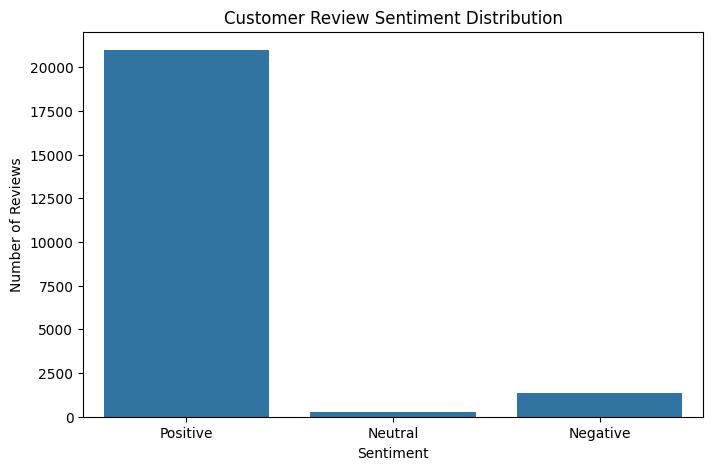

In [26]:
# Sentiment Distribution Dashboard

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Sentiment',
    order=['Positive', 'Neutral', 'Negative']
)

plt.title('Customer Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()


In [27]:
## Sentiment Percentage Analysis

sentiment_percentages = (
    df['Sentiment']
    .value_counts(normalize=True)
    * 100
).round(2)

print(sentiment_percentages)

Sentiment
Positive    92.69
Negative     6.08
Neutral      1.23
Name: proportion, dtype: float64


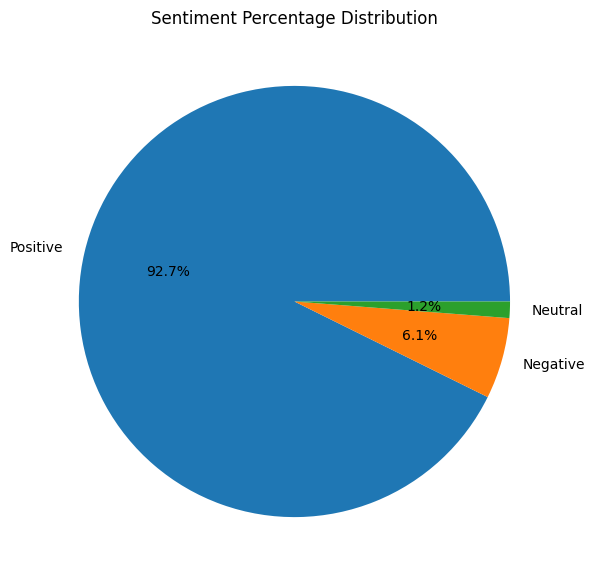

In [28]:
## Sentiment Share

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_percentages,
    labels=sentiment_percentages.index,
    autopct='%1.1f%%'
)

plt.title('Sentiment Percentage Distribution')

plt.show()

In [29]:
## Key Business Insights
print("Total Reviews Analysed :", len(df))
print("Positive Reviews :", sentiment_counts['Positive'])
print("Negative Reviews :", sentiment_counts['Negative'])
print("Neutral Reviews :", sentiment_counts['Neutral'])

Total Reviews Analysed : 22641
Positive Reviews : 20987
Negative Reviews : 1376
Neutral Reviews : 278


In [ ]:
## Conclusion

This project successfully analysed customer reviews using the VADER Sentiment Analysis model.

The dataset contained more than 22,000 customer reviews from an e-commerce clothing platform. After cleaning the data, sentiment scores were generated for every review and classified as Positive, Neutral, or Negative.

Results showed that approximately 93% of customer reviews were positive, indicating high customer satisfaction. Only a small percentage of reviews were negative or neutral.

The sentiment dashboard provides a simple and effective way to monitor customer feedback and understand customer opinions. Businesses can use these insights to improve products, identify customer concerns, and enhance overall customer experience.